In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [57]:
try :
    df = pd.read_csv("dataset/sales1.csv")
    print("File berhasil di masukkan")
    
except FileNotFoundError:
    print("File tidak di temukan")

File berhasil di masukkan


In [7]:
df.head()

,order_id,date,store,product,quantity,sales
0,1,01/01/2023,Lower Manhattan,Gourmet brewed coffee,2,6.0
1,2,01/01/2023,Lower Manhattan,Brewed Chai tea,2,6.2
2,3,01/01/2023,Lower Manhattan,Hot chocolate,2,9.0
3,4,01/01/2023,Lower Manhattan,Drip coffee,1,2.0
4,5,01/01/2023,Lower Manhattan,Brewed Chai tea,2,6.2


In [11]:
df.shape

(149116, 6)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   order_id  149116 non-null  int64  
 1   date      149116 non-null  object 
 2   store     149116 non-null  object 
 3   product   149116 non-null  object 
 4   quantity  149116 non-null  int64  
 5   sales     149116 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 6.8+ MB


In [13]:
- df.isnull().sum()

order_id    0
date        0
store       0
product     0
quantity    0
sales       0
dtype: int64

In [15]:
df.describe()

,order_id,quantity,sales
count,149116.000000,149116.000000,149116.000000
mean,74737.371872,1.438276,4.686367
std,43153.600016,0.542509,4.227099
min,1.000000,1.000000,0.800000
25%,37335.750000,1.000000,3.000000
50%,74727.500000,1.000000,3.750000
75%,112094.250000,2.000000,6.000000
max,149456.000000,8.000000,360.000000


In [26]:
df[df['store']=="Astoria"].describe()

,order_id,quantity,sales
count,50599.000000,50599.000000,50599.000000
mean,75046.022431,1.403012,4.589891
std,43264.198245,0.490508,2.877599
min,106.000000,1.000000,0.800000
25%,37270.500000,1.000000,3.000000
50%,75240.000000,1.000000,3.750000
75%,112307.500000,2.000000,6.000000
max,149449.000000,2.000000,45.000000


In [28]:
df.skew(numeric_only=True)

order_id     0.000062
quantity     0.799819
sales       41.745899
dtype: float64

In [32]:
df.kurtosis(numeric_only=True)

order_id      -1.200451
quantity       0.823692
sales       3359.754589
dtype: float64

array([[<Axes: title={'center': 'order_id'}>,
        <Axes: title={'center': 'quantity'}>],
       [<Axes: title={'center': 'sales'}>, <Axes: >]], dtype=object)

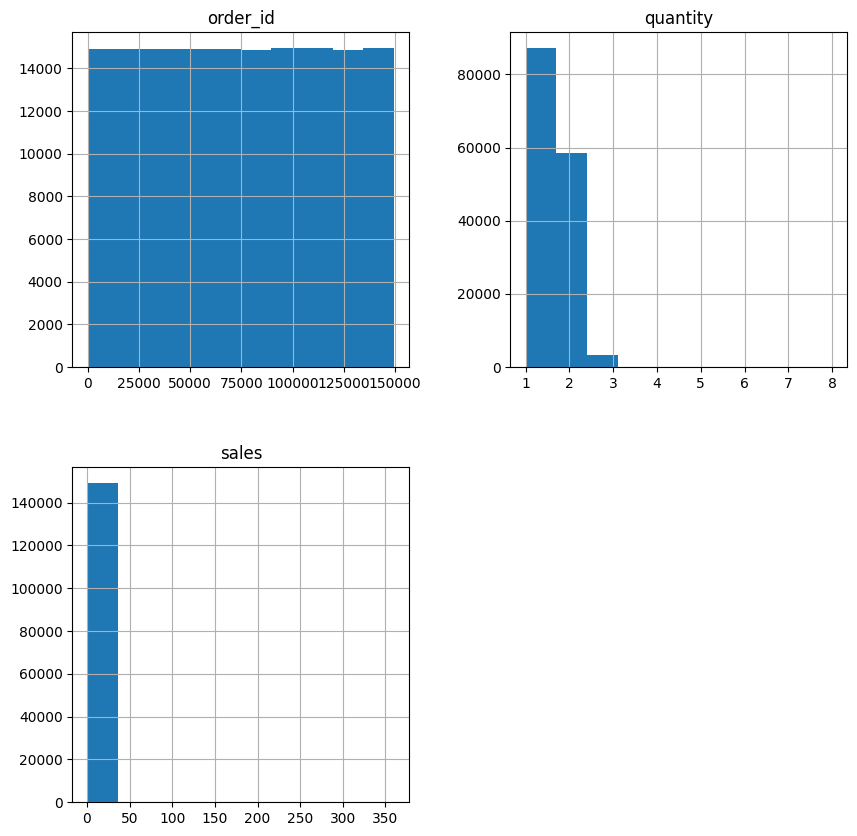

In [ ]:
features = ['order_id', 'quantity', 'sales'] # ini jadi list kolom yang isinya interger
df[features].hist(figsize=(10,10))

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

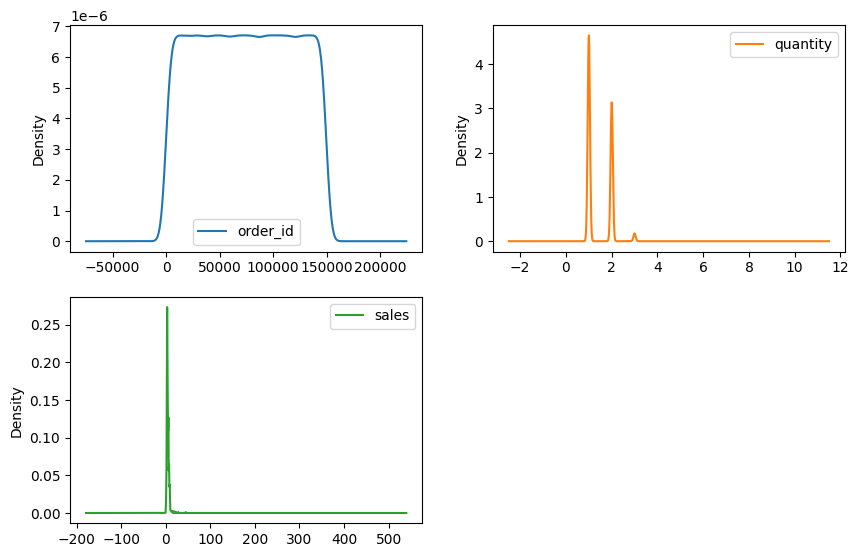

In [35]:
df[features].plot(kind='density', subplots=True, layout=(3, 2), sharex=False, figsize=(10, 10))

<Axes: xlabel='order_id'>

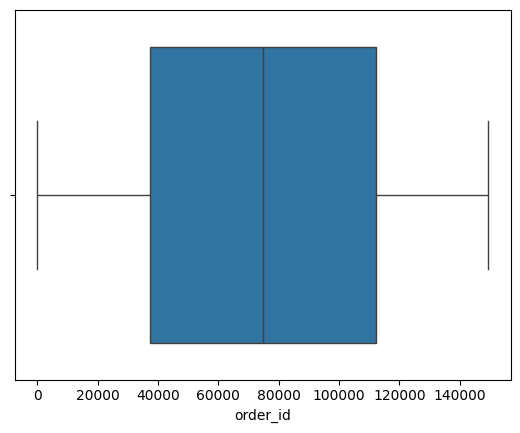

In [ ]:
sns.boxplot(x='order_id', data=df) #bisa pakai kolom manapun sesuai dengan yang ada di csv kita, harus mirip. aku pakai order_id biar kelihatan bagus aja

<Axes: xlabel='sales'>

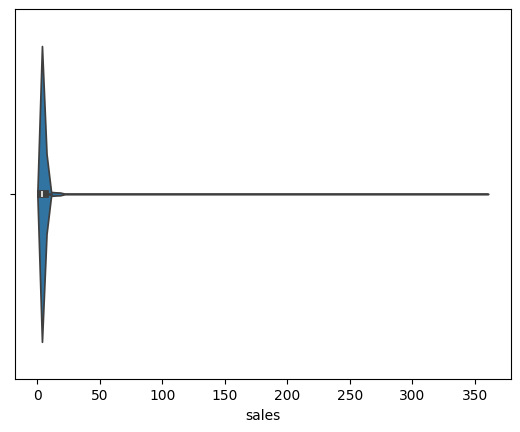

In [ ]:
sns.violinplot(x='sales', data=df) #ini contoh pakai sales, bentuknya memang sedikit unik karena datanya banyak

Text(0.5, 1.0, 'Stores')

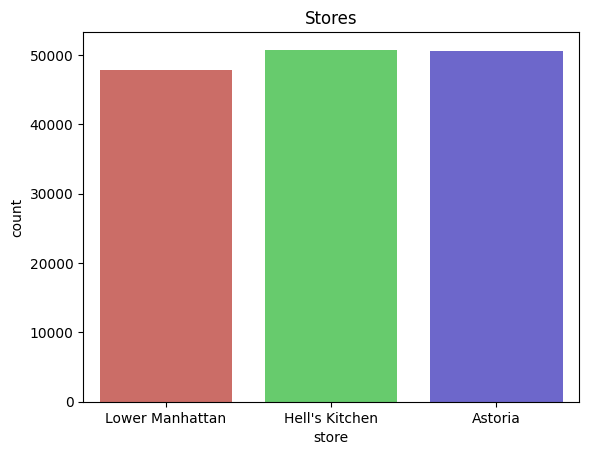

In [53]:
sns.countplot(x='store', data=df, palette="hls") #ini menunjukkan semua data dari data frame kelompok store dan di jadikan bar chart
plt.title("Stores")

Text(0.5, 1.0, 'Distribusi Store Astoria')

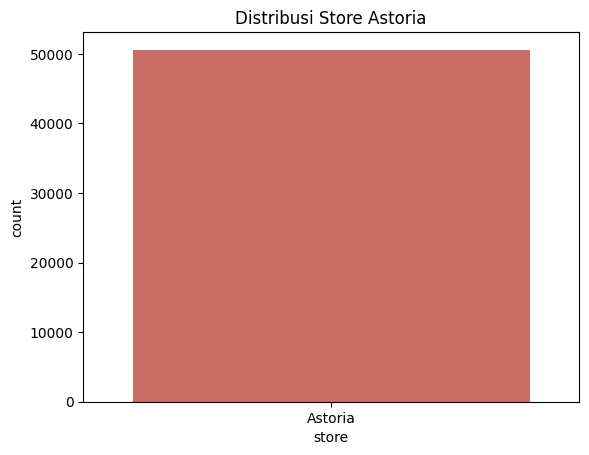

In [63]:
df_astoria = df[df['store'] == 'Astoria']

sns.countplot(x='store', data=df_astoria, palette="hls")
plt.title("Distribusi Store Astoria")

In [60]:
df.corr(numeric_only=True)

,order_id,quantity,sales
order_id,1.000000,0.010250,0.005949
quantity,0.010250,1.000000,0.356231
sales,0.005949,0.356231,1.000000


Text(0.5, 1.0, 'Heatmap Korelasi')

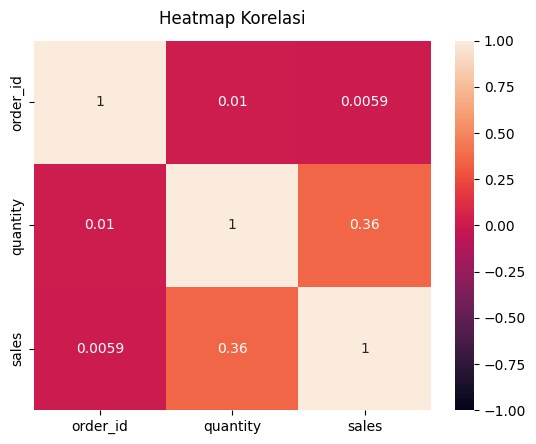

In [61]:
heatmap = sns.heatmap(df.corr(numeric_only=True), vmin=-1,vmax=1, annot=True)
heatmap.set_title('Heatmap Korelasi', fontdict={'fontsize':12}, pad= 12)

<Axes: xlabel='quantity', ylabel='product'>

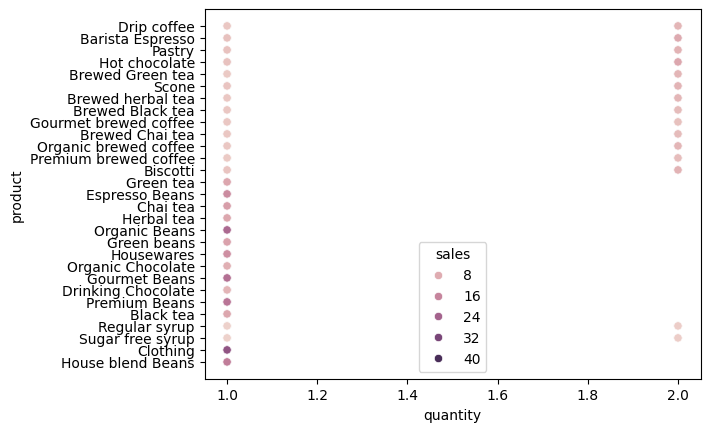

In [70]:
sns.scatterplot(x='quantity', y="product", hue = "sales", data= df_astoria)

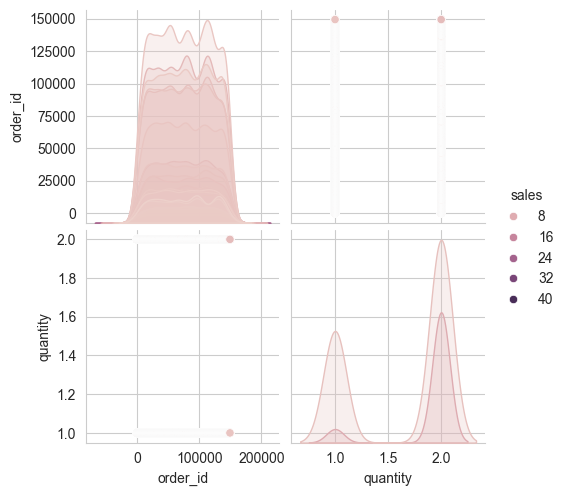

In [71]:
sns.set_style("whitegrid")
sns.pairplot(df_astoria, hue="sales")
plt.show()

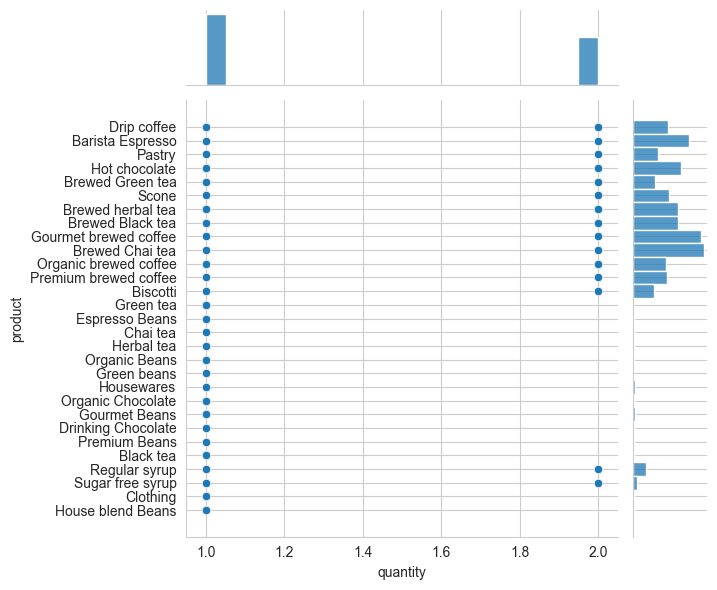

In [73]:
sns.jointplot(x = 'quantity', y = 'product', data = df_astoria)

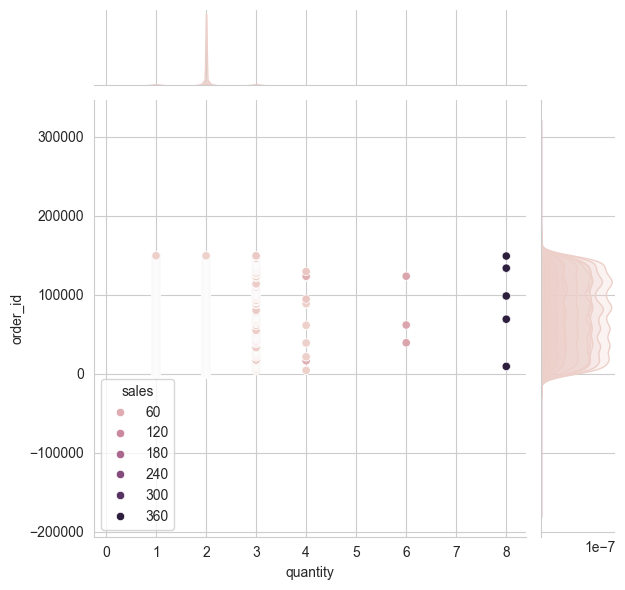

In [ ]:
sns.jointplot(x = 'quantity', y = 'order_id', data = df_astoria ,hue ="sales")

<Axes: xlabel='quantity', ylabel='product'>

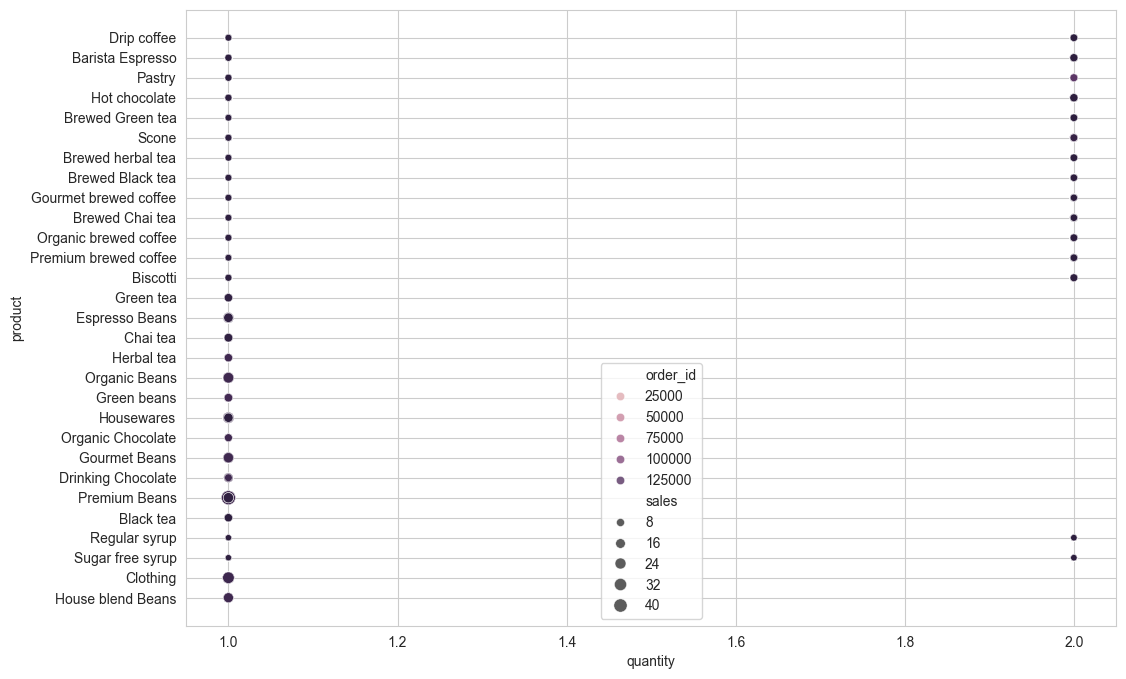

In [79]:
plt.figure(figsize=(12,8))
sns.scatterplot(x="quantity", 
                y="product",
                size="sales",
                sizes=(20,100),
                alpha=0.8,
                hue="order_id",
                data=df_astoria)

Conlusion

Through this lesson, I gained a practical understanding of the data science process and learned why each phase matters. I now see that data science is not just about building models—it is a complete workflow that begins with collecting data, then cleaning it, exploring it, building models, and finally deploying them. By working through the early stages, I realized that skipping or rushing exploratory data analysis can lead to poor modeling choices later. This lesson taught me that investing time to understand your data upfront is essential, not optional.

I also learned that exploratory data analysis is far more than just making charts. It is about asking questions and letting the data answer. When I explored the sales dataset, I discovered patterns I would have otherwise missed. For example, I saw which stores had the highest number of transactions, noticed that quantity and sales are only moderately correlated, and identified products that are sold much more frequently than others. These insights are not just interesting—they are directly useful for deciding which features might be important if I were to build a predictive model.

Another important lesson was that EDA is not a one-size-fits-all step. It combines both numerical summaries and visualizations, and each serves a distinct purpose. Descriptive statistics gave me a quick overview, but visualizations helped me actually see the story behind the numbers. I learned to use non-graphical methods like .head(), .shape(), .info(), and .corr() to inspect the data and check for missing values or relationships between numeric columns. Then I moved to graphical analysis using Matplotlib and Seaborn, where I created a wide range of plots.

With univariate plots, I examined single variables in depth. Density plots showed me the distribution of sales and quantity, boxplots and violinplots revealed spread and skew, and countplots made it immediately obvious which stores had the highest order volume. With multivariate plots, I explored how variables interact. A correlation heatmap gave me a clean visual summary of relationships, scatterplots let me compare quantity and product while coloring by sales value, and pairplots offered a multi-perspective view in one figure.

One of the most valuable techniques I picked up is the ability to filter the data to focus on a specific subset. By taking only the rows where the store is Astoria, I could analyze that location in isolation. This allowed me to create more focused visualizations—like jointplots and styled scatterplots—without the noise from other stores. The patterns became clearer and much easier to interpret. I also discovered how much more expressive a plot can be when I add extra dimensions through color, point size, or transparency. Using hue, size, and alpha turned simple scatterplots into rich, multi-layered visuals.

By completing this lesson, I did not just learn how to use Seaborn or Matplotlib. I learned how to think like someone who explores data for a living. I now understand that a moderate correlation—like the 0.36 between quantity and sales—tells me that quantity alone is not a strong predictor; I would need other features or more complex models. I also learned that visualizing subsets of data can uncover insights that are invisible in the full dataset. And most importantly, I realized that the tools we use are only as good as the questions we ask with them.

This lesson gave me a framework I can apply to any dataset. I now feel more confident starting a data project, knowing that the early steps of collecting, inspecting, and visualizing are just as important as the modeling that comes later.